# Smart Meter Portfolio Insights

This notebook runs curated Athena analysis queries and passes each result to chart functions from `src/export_portfolio_images.py`.

In [1]:
from pathlib import Path
import sys
import importlib
import boto3
from IPython.display import Image, display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / 'src'))

import export_portfolio_images as epi
epi = importlib.reload(epi)

_chart_concentration = epi._chart_concentration
_chart_dno_share = epi._chart_dno_share
_chart_dno_outlier_screen = epi._chart_dno_outlier_screen
_chart_load_shape = epi._chart_load_shape
_chart_peak_hour_distribution = epi._chart_peak_hour_distribution
_chart_weekday_weekend = epi._chart_weekday_weekend
_run_sql = epi._run_sql

AWS_REGION = 'eu-west-2'
DATABASE = 'energy_smart_meter'
WORKGROUP = 'energy-smart-meter-pipeline-dev-athena'
ATHENA_OUTPUT_S3_URI = 's3://smart-meter-athena-results/athena-results/'
OUT_DIR = REPO_ROOT / 'docs' / 'images'
INSIGHTS_DIR = REPO_ROOT / 'sql' / 'insights'

athena = boto3.client('athena', region_name=AWS_REGION)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'repo_root={REPO_ROOT}')
print(f'out_dir={OUT_DIR}')
print(f'export_module={epi.__file__}')


repo_root=/Users/wbutler/Documents/Github/uk-smart-meter-data
out_dir=/Users/wbutler/Documents/Github/uk-smart-meter-data/docs/images
export_module=/Users/wbutler/Documents/Github/uk-smart-meter-data/src/export_portfolio_images.py


## 1. DNO Share of Total Demand

A Distribution Network Operator (DNO) is a licensed company responsible for operating and maintaining the local electricity distribution network—poles, cables, and transformers—that delivers power to homes and businesses

This chart shows how total consumption is split across DNO regions, highlighting regional concentration.

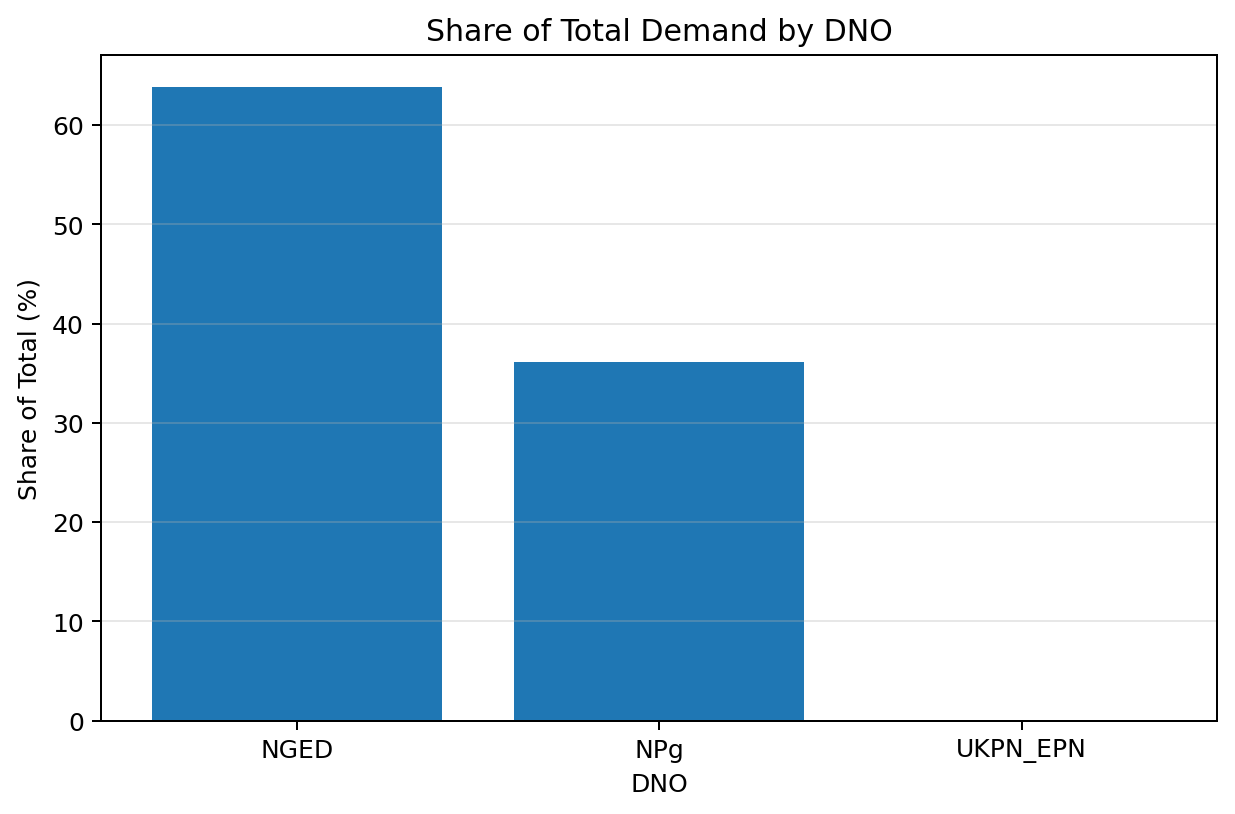

,dno_alias,total_consumption,share_of_total
0,NGED,6.188623e+12,0.638501
1,NPg,3.499477e+12,0.361053
2,UKPN_EPN,4.324200e+09,0.000446


In [2]:
sql = (INSIGHTS_DIR / '11_dno_share_of_total.sql').read_text(encoding='utf-8')
df = _run_sql(
    athena,
    sql=sql,
    database=DATABASE,
    output_location=ATHENA_OUTPUT_S3_URI,
    workgroup=WORKGROUP,
)
image_path = _chart_dno_share(df, OUT_DIR)
display(Image(filename=str(image_path)))
df.head()

## 2. DNO Outlier Screen

This chart compares each DNO's mean-to-median substation demand ratio. 
Higher values indicate a more skewed demand distribution and stronger concentration in high-demand substations.

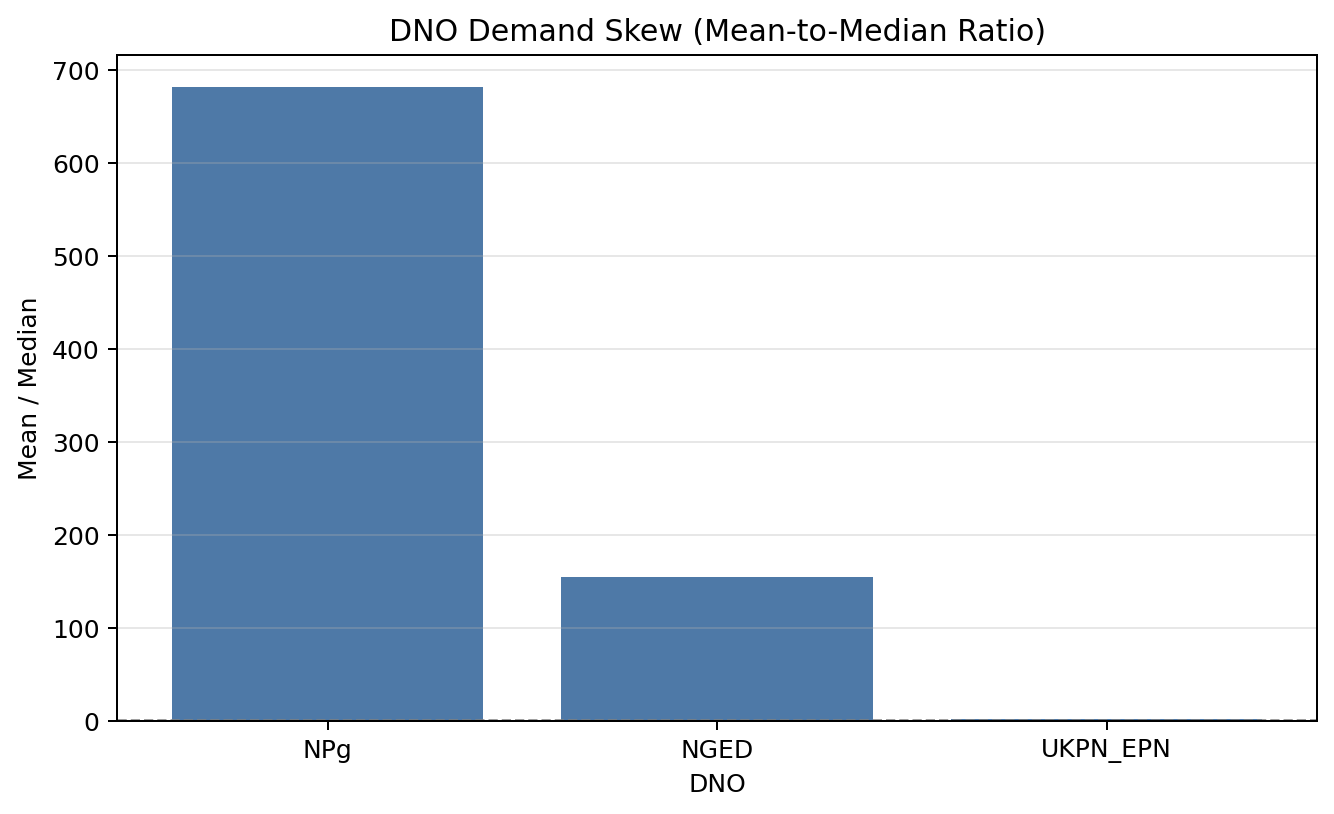

,dno_alias,dno_mean,dno_median,mean_to_median_ratio
0,NPg,2.3989259833802742E8,351761.6543337777,681.974841
1,NGED,9.102260481063133E7,587806.8598500193,154.851212
2,UKPN_EPN,513860.8734015369,437961.57554142224,1.173301


In [3]:
sql = (INSIGHTS_DIR / '10_dno_outlier_screen.sql').read_text(encoding='utf-8')
df = _run_sql(
    athena,
    sql=sql,
    database=DATABASE,
    output_location=ATHENA_OUTPUT_S3_URI,
    workgroup=WORKGROUP,
)
image_path = _chart_dno_outlier_screen(df, OUT_DIR)
display(Image(filename=str(image_path)))
df

## 3. Peak Hour Distribution

This distribution shows the time-of-day when substations hit their daily peak.

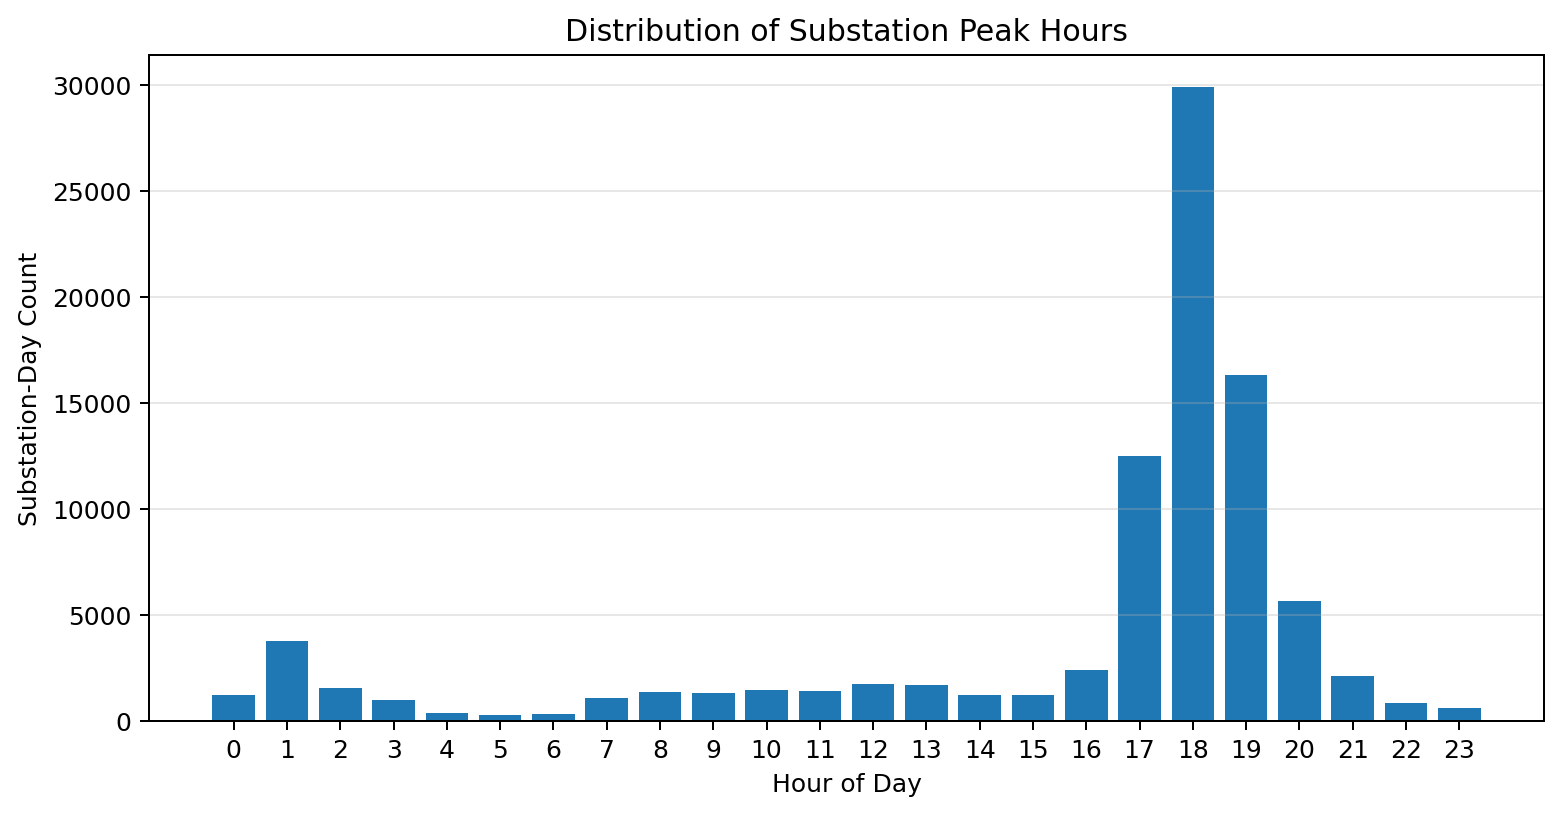

,peak_hour,substation_days
0,0,1187
1,1,3759
2,2,1533
3,3,975
4,4,341


In [4]:
sql = (INSIGHTS_DIR / '12_peak_hour_distribution.sql').read_text(encoding='utf-8')
df = _run_sql(
    athena,
    sql=sql,
    database=DATABASE,
    output_location=ATHENA_OUTPUT_S3_URI,
    workgroup=WORKGROUP,
)
image_path = _chart_peak_hour_distribution(df, OUT_DIR)
display(Image(filename=str(image_path)))
df.head()

## 4. Top-10 Demand Concentration

This chart shows cumulative concentration among top-ranked substations.

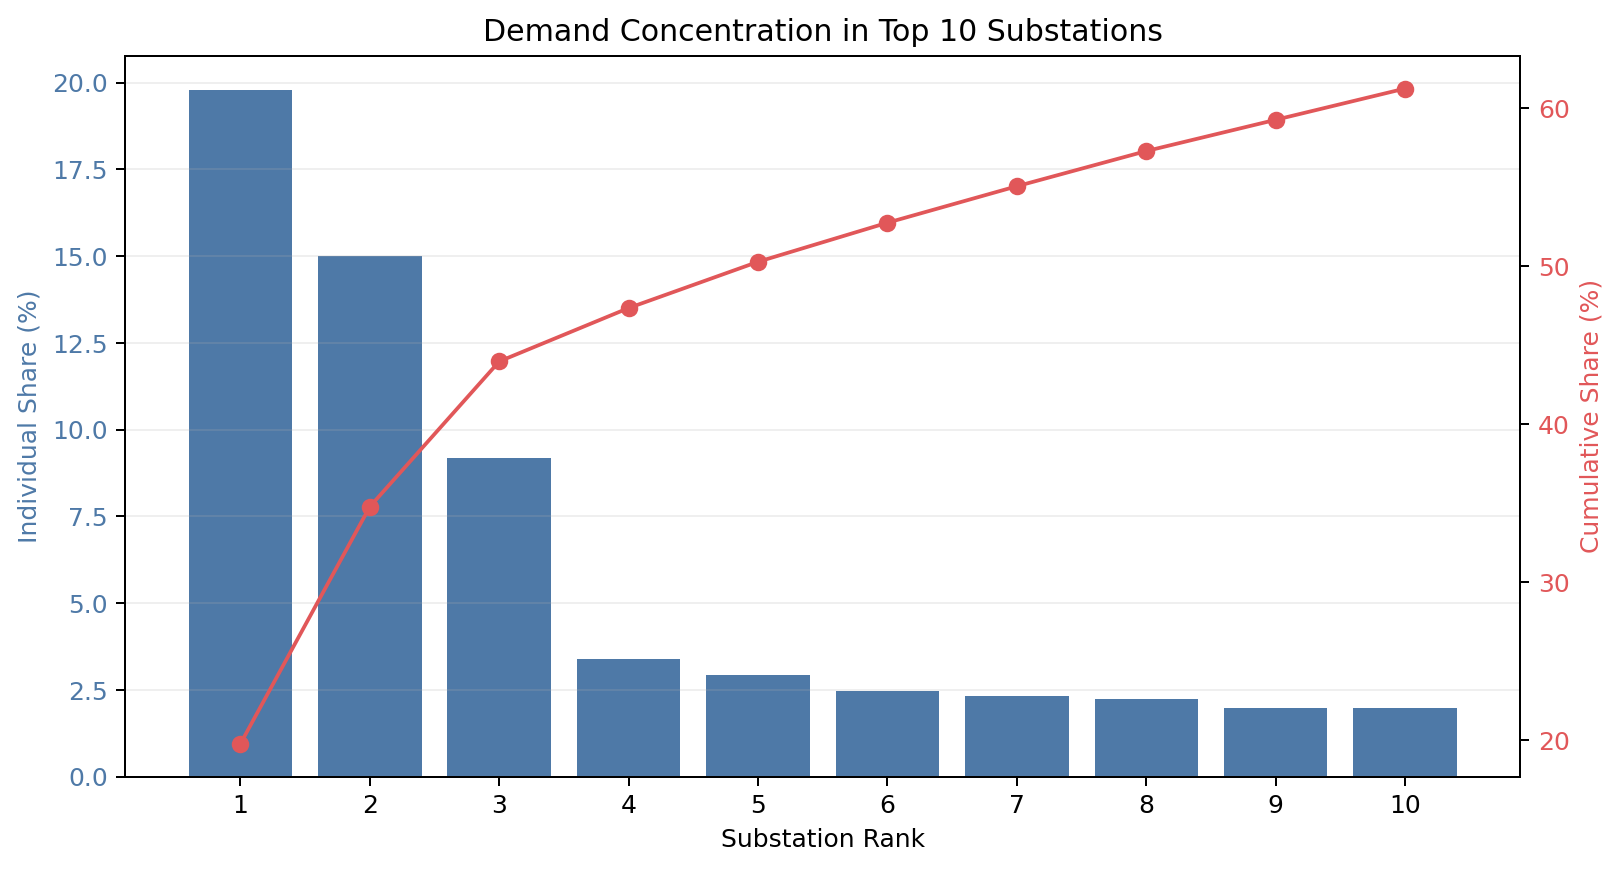

,rn,secondary_substation_unique_id,total_consumption,fleet_total_consumption,share_of_total
0,1,148549992-GOSFORTH LANSDOWNE,2.061601e+12,1.0418039990278E13,0.197888
1,2,942655-FALCON AVENUE SPRINGFIELD,1.563383e+12,1.0418039990278E13,0.150065
2,3,874204-FIELDS FARM LONG EATON,9.577979e+11,1.0418039990278E13,0.091936
3,4,933996-RENE RD G084 AMINN,3.521972e+11,1.0418039990278E13,0.033806
4,5,853919-Gladstone Way - Stafford,3.049593e+11,1.0418039990278E13,0.029272


In [5]:
sql = (INSIGHTS_DIR / '06_substation_concentration.sql').read_text(encoding='utf-8')
df = _run_sql(
    athena,
    sql=sql,
    database=DATABASE,
    output_location=ATHENA_OUTPUT_S3_URI,
    workgroup=WORKGROUP,
)
image_path = _chart_concentration(df, OUT_DIR)
display(Image(filename=str(image_path)))
df.head()

## 5. Weekday vs Weekend Evening Ramp

This compares evening demand intensity against overnight baseline for weekdays and weekends.

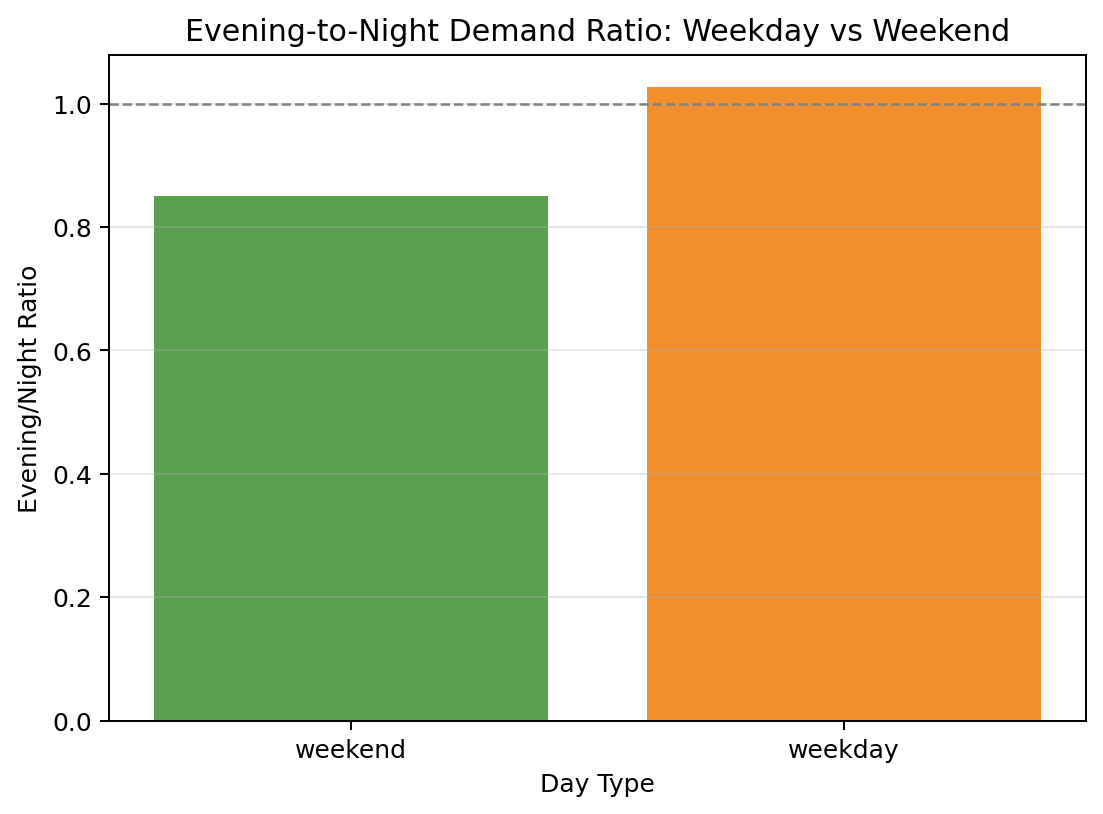

,day_type,evening_avg,night_avg,evening_to_night_ratio
0,weekend,4.538162e+05,5.341145e+05,0.849661
1,weekday,1.343999e+06,1.308370e+06,1.027231


In [6]:
sql = (INSIGHTS_DIR / '09_evening_ramp_weekday_vs_weekend.sql').read_text(encoding='utf-8')
df = _run_sql(
    athena,
    sql=sql,
    database=DATABASE,
    output_location=ATHENA_OUTPUT_S3_URI,
    workgroup=WORKGROUP,
)
image_path = _chart_weekday_weekend(df, OUT_DIR)
display(Image(filename=str(image_path)))
df

## Exported Files

All generated PNG files are saved in `docs/images/`.

In [ ]:
for p in sorted(OUT_DIR.glob('*.png')):
    print(p.relative_to(REPO_ROOT))
